In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [22]:
file_path = "../dataset/Customer_Segmentation_py.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (113036, 18)


In [23]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [24]:
# Check dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (113036, 18)

Column Data Types:
Date                object
Day                  int64
Month               object
Year                 int64
Customer_Age         int64
Age_Group           object
Customer_Gender     object
Country             object
State               object
Product_Category    object
Sub_Category        object
Product             object
Order_Quantity       int64
Unit_Cost            int64
Unit_Price           int64
Profit               int64
Cost                 int64
Revenue              int64
dtype: object

Missing Values:
Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64


In [25]:
# Detailed dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [26]:
# Basic statistical overview
df.describe()

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


In [27]:
numeric_columns = df.select_dtypes(include='number').columns

print("Numerical columns:")
print(numeric_columns.tolist())

Numerical columns:
['Day', 'Year', 'Customer_Age', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']


In [28]:
descriptive_stats = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Mode': df[numeric_columns].mode().iloc[0],
    'Standard Deviation': df[numeric_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
Day,15.665753,16.0,24.0,8.781567
Year,2014.401739,2014.0,2014.0,1.272510
Customer_Age,35.919212,35.0,31.0,11.021936
Order_Quantity,11.901660,10.0,1.0,9.561857
Unit_Cost,267.296366,9.0,2.0,549.835483
Unit_Price,452.938427,24.0,5.0,922.071219
Profit,285.051665,101.0,3.0,453.887443
Cost,469.318695,108.0,1252.0,884.866118
Revenue,754.370360,223.0,35.0,1309.094674


### Descriptive Statistics

Descriptive statistics were calculated for all numerical variables to understand their central tendency and variability. Mean and median provide measures of central tendency, while mode identifies the most frequently occurring value. Standard deviation indicates the variation in each numerical variable.

In [29]:
df['Date'] = pd.to_datetime(df['Date'])

print("Date converted successfully!")
print(df['Date'].dtype)

C:\Users\saisp\AppData\Local\Temp\ipykernel_13676\560671378.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


Date converted successfully!
datetime64[ns]


In [30]:
df['Year_Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Year_Month')['Revenue'].sum()

monthly_revenue.head()

Year_Month
2011-01    675193
2011-02    637598
2011-03    708517
2011-04    698782
2011-05    734537
Freq: M, Name: Revenue, dtype: int64

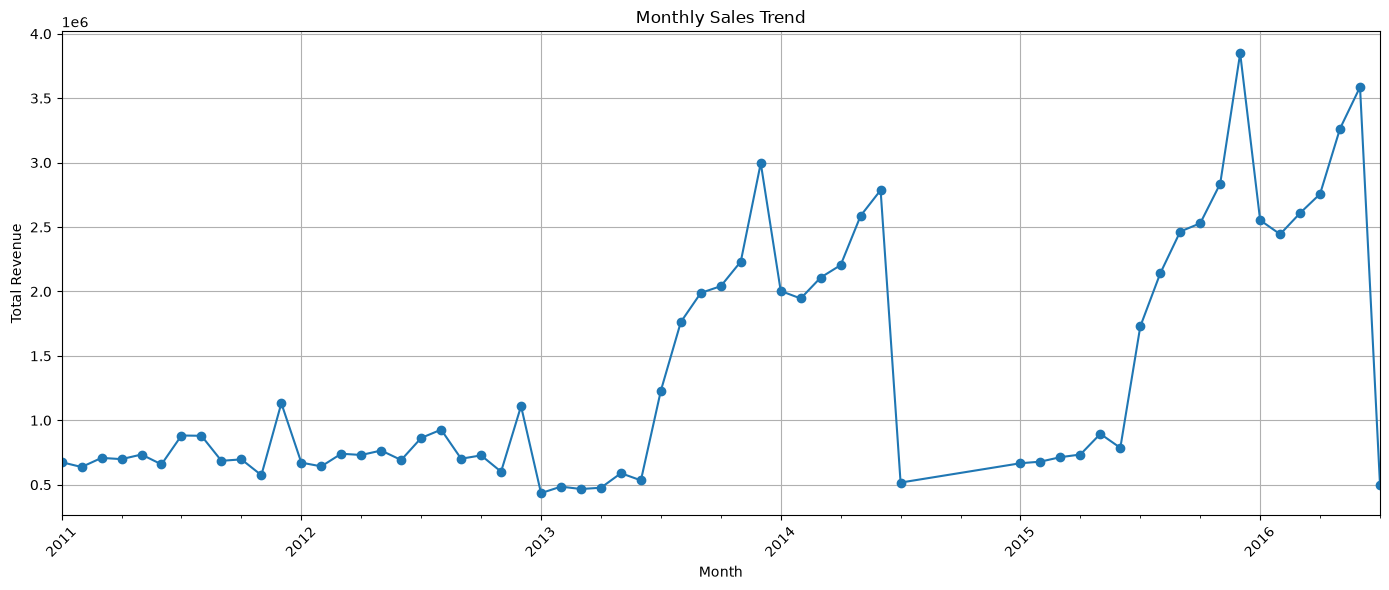

In [31]:
plt.figure(figsize=(14, 6))

monthly_revenue.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Observation – Monthly Sales Trend

The monthly sales analysis shows noticeable fluctuations in revenue across the years, with several periods of sharp increases and decreases. Sales generally show stronger performance during certain months, indicating seasonal variation in customer purchasing behaviour. The later years also show higher revenue peaks compared with the earlier period, suggesting overall growth in sales performance.

In [32]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_revenue = df.groupby('Quarter')['Revenue'].sum()

quarterly_revenue

Quarter
2011Q1    2021308
2011Q2    2091457
2011Q3    2448010
2011Q4    2404113
2012Q1    2055176
2012Q2    2188536
2012Q3    2492751
2012Q4    2439520
2013Q1    1387408
2013Q2    1600693
2013Q3    4982778
2013Q4    7269158
2014Q1    6057640
2014Q2    7578197
2014Q3     516887
2015Q1    2060192
2015Q2    2416131
2015Q3    6334151
2015Q4    9213517
2016Q1    7605918
2016Q2    9607507
2016Q3     499960
Freq: Q-DEC, Name: Revenue, dtype: int64

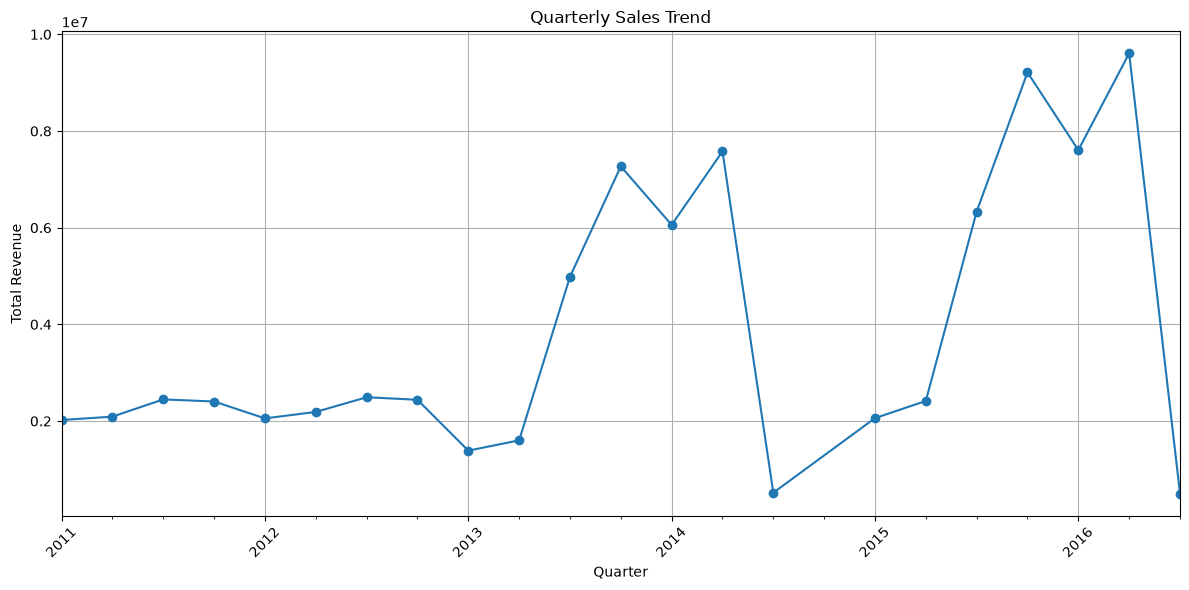

In [33]:
plt.figure(figsize=(12, 6))

quarterly_revenue.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Observation – Quarterly Sales Trend

The quarterly sales analysis shows significant variation in revenue across the study period. Sales remain relatively stable during the earlier years, followed by a substantial increase from 2013 onward. The highest revenue levels are observed during the later periods, particularly around 2015 and 2016, indicating strong growth in overall sales performance. However, sharp declines between certain quarters suggest seasonal or periodic fluctuations in customer demand. The business can use these patterns to plan inventory, marketing campaigns, and resources ahead of high-revenue periods.

In [34]:
print("Age Groups:")
print(df['Age_Group'].value_counts())

Age Groups:
Age_Group
Adults (35-64)          55824
Young Adults (25-34)    38654
Youth (<25)             17828
Seniors (64+)             730
Name: count, dtype: int64


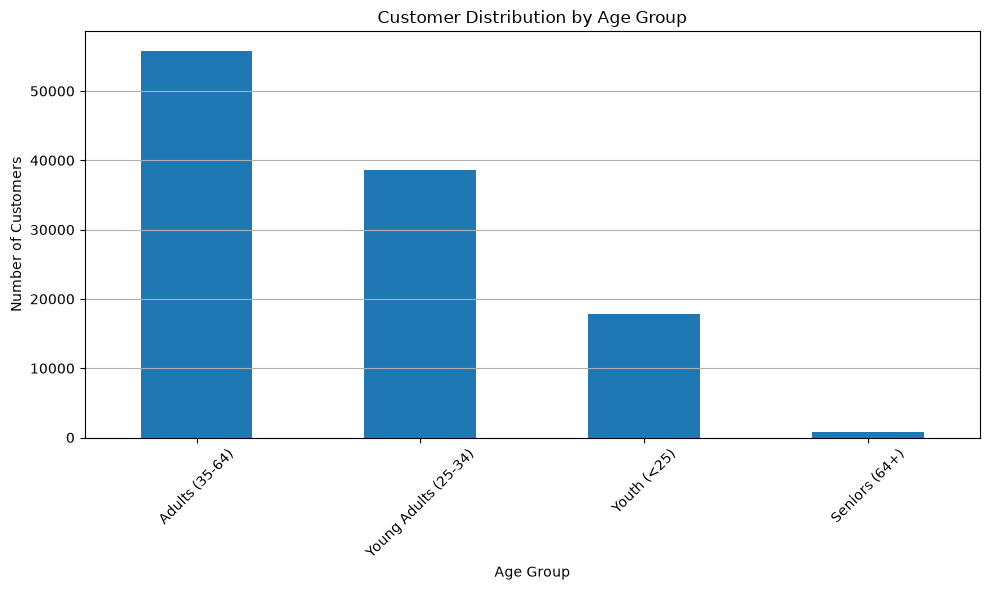

In [35]:
age_group_counts = df['Age_Group'].value_counts()

plt.figure(figsize=(10, 6))

age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()

plt.show()

### Observation – Customer Age Group Distribution

The customer age-group analysis shows that Adults (35–64) form the largest customer segment, followed by Young Adults (25–34). Youth (<25) account for a smaller share of customers, while Seniors (64+) represent the smallest segment. This indicates that the business has a stronger customer base among adults and young adults, suggesting that marketing campaigns and product offerings can be primarily tailored to these age groups while developing targeted strategies to increase engagement among younger and senior customers.

In [36]:
gender_counts = df['Customer_Gender'].value_counts()

print("Customer Gender Distribution:")
print(gender_counts)

Customer Gender Distribution:
Customer_Gender
M    58312
F    54724
Name: count, dtype: int64


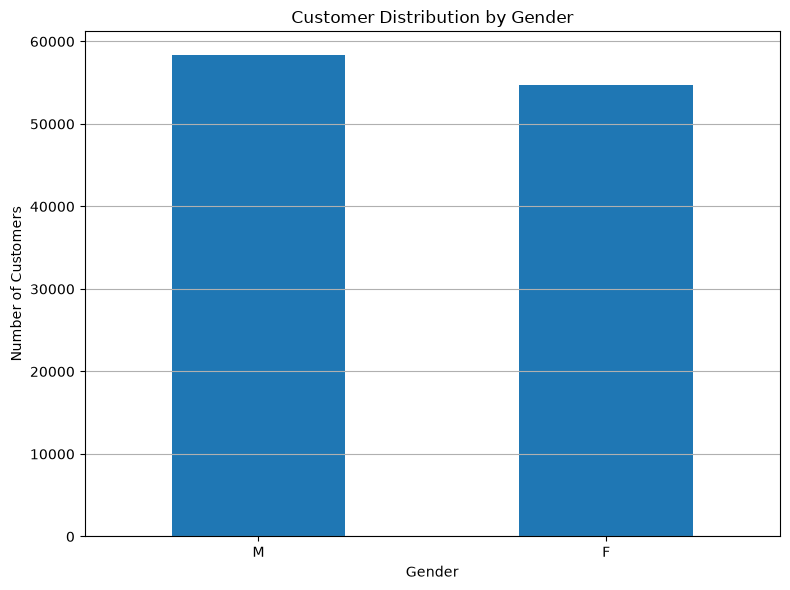

In [37]:
plt.figure(figsize=(8, 6))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()

plt.show()

### Observation – Customer Gender Distribution

The gender distribution shows a relatively balanced customer base, with male customers representing a slightly larger share than female customers. The difference is not substantial, indicating that the business attracts customers from both genders. Marketing strategies can therefore target both groups while using gender-specific campaigns where purchasing behaviour supports them.

In [39]:
top_products = (
    df.groupby('Product')['Order_Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print("Top 10 Best-Selling Products:")
print(top_products)

Top 10 Best-Selling Products:
Product
Water Bottle - 30 oz.      164086
Patch Kit/8 Patches        157583
Mountain Tire Tube         102792
AWC Logo Cap                67316
Sport-100 Helmet, Red       63663
Road Tire Tube              62296
Fender Set - Mountain       62118
Sport-100 Helmet, Black     62105
Touring Tire Tube           56802
Sport-100 Helmet, Blue      55895
Name: Order_Quantity, dtype: int64


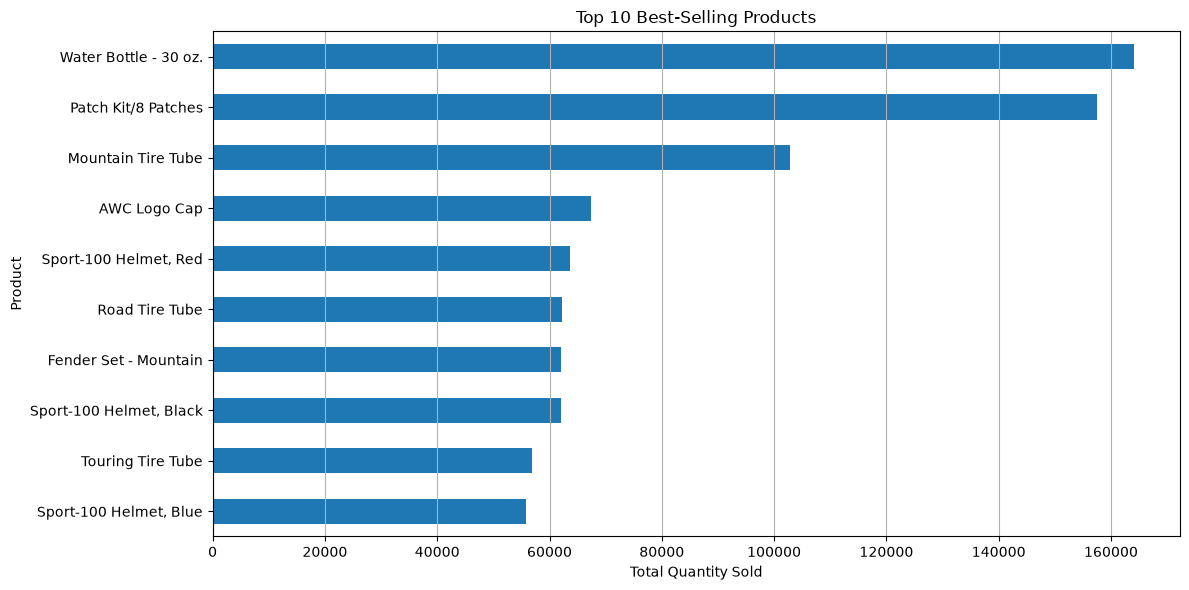

In [40]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.grid(axis='x')
plt.tight_layout()

plt.show()

### Observation – Top 10 Best-Selling Products

The top-selling product is Water Bottle – 30 oz., with 164,086 units sold, followed closely by Patch Kit/8 Patches with 157,583 units. Mountain Tire Tube ranks third with 102,792 units. The remaining top products include accessories, tires, and helmets, indicating strong demand for both cycling accessories and equipment. The business can maintain sufficient inventory for these high-demand products and use them as key products in promotional campaigns.

In [41]:
category_revenue = (
    df.groupby('Product_Category')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

print("Revenue by Product Category:")
print(category_revenue)

Revenue by Product Category:
Product_Category
Bikes          61782134
Accessories    15117992
Clothing        8370882
Name: Revenue, dtype: int64


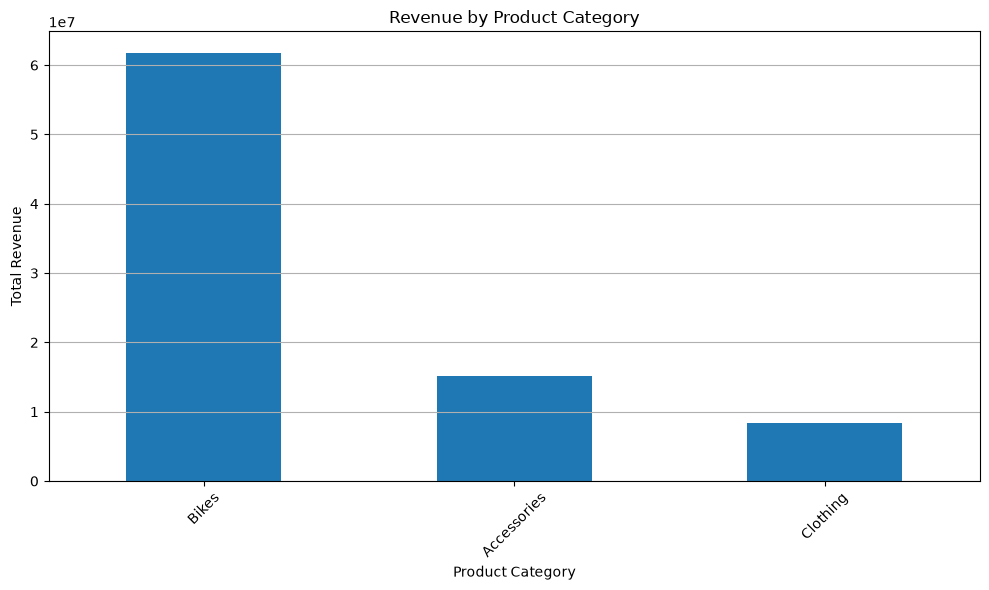

In [42]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()

plt.show()

### Observation – Revenue by Product Category

The revenue analysis shows that Bikes generate the highest revenue among all product categories, followed by Accessories. Clothing contributes the lowest revenue. The strong performance of the Bikes category indicates that it is the primary revenue-generating category for the business. The company should maintain adequate inventory and promotional support for Bikes while exploring opportunities to increase revenue from Accessories and Clothing.

In [43]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
Day,1.000000,-0.007635,-0.014296,-0.002412,0.003133,0.003207,0.004623,0.003329,0.003853
Year,-0.007635,1.000000,0.040994,0.123169,-0.217575,-0.213673,-0.181525,-0.215604,-0.208673
Customer_Age,-0.014296,0.040994,1.000000,0.026887,-0.021374,-0.020262,0.004319,-0.016013,-0.009326
Order_Quantity,-0.002412,0.123169,0.026887,1.000000,-0.515835,-0.515925,-0.238863,-0.340382,-0.312895
Unit_Cost,0.003133,-0.217575,-0.021374,-0.515835,1.000000,0.997894,0.741020,0.829869,0.817865
Unit_Price,0.003207,-0.213673,-0.020262,-0.515925,0.997894,1.000000,0.749870,0.826301,0.818522
Profit,0.004623,-0.181525,0.004319,-0.238863,0.741020,0.749870,1.000000,0.902233,0.956572
Cost,0.003329,-0.215604,-0.016013,-0.340382,0.829869,0.826301,0.902233,1.000000,0.988758
Revenue,0.003853,-0.208673,-0.009326,-0.312895,0.817865,0.818522,0.956572,0.988758,1.000000


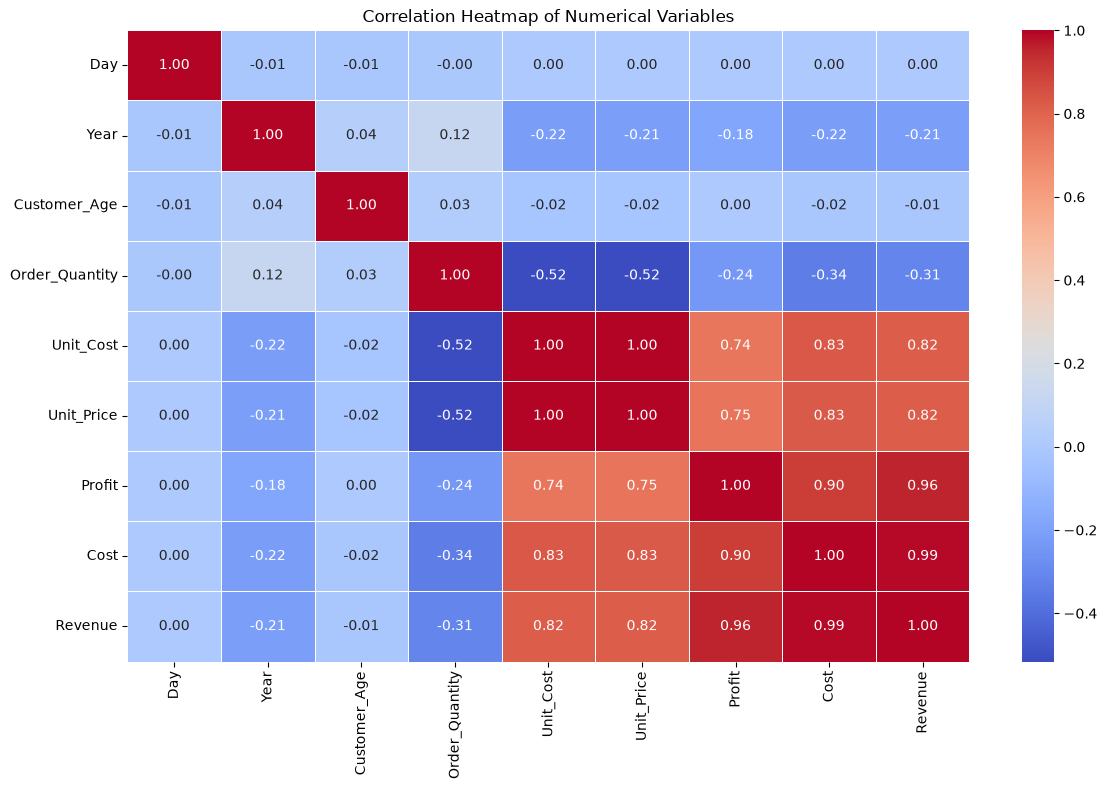

In [44]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()

plt.show()

### Observation – Correlation Heatmap

The correlation analysis shows strong positive relationships among several financial variables. Cost and Revenue have the strongest correlation at 0.99, followed by Profit and Revenue at 0.96 and Profit and Cost at 0.90. Unit Cost and Unit Price also show strong positive relationships with Revenue, both at approximately 0.82. In contrast, Order Quantity has moderate negative correlations with Unit Cost and Unit Price, both around -0.52. These relationships indicate that financial performance variables are closely connected and should be considered together when analysing sales and profitability.

In [45]:
category_profit = (
    df.groupby('Product_Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print("Profit by Product Category:")
print(category_profit)

Profit by Product Category:
Product_Category
Bikes          20519276
Accessories     8862377
Clothing        2839447
Name: Profit, dtype: int64


In [47]:
category_summary = df.groupby('Product_Category').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
})

category_summary['Profit_Margin_%'] = (
    category_summary['Profit'] / category_summary['Revenue']
) * 100

category_summary = category_summary.sort_values(
    'Profit_Margin_%',
    ascending=False
)

category_summary

,Revenue,Profit,Profit_Margin_%
Product_Category,,,
Accessories,15117992,8862377,58.621390
Clothing,8370882,2839447,33.920524
Bikes,61782134,20519276,33.212313


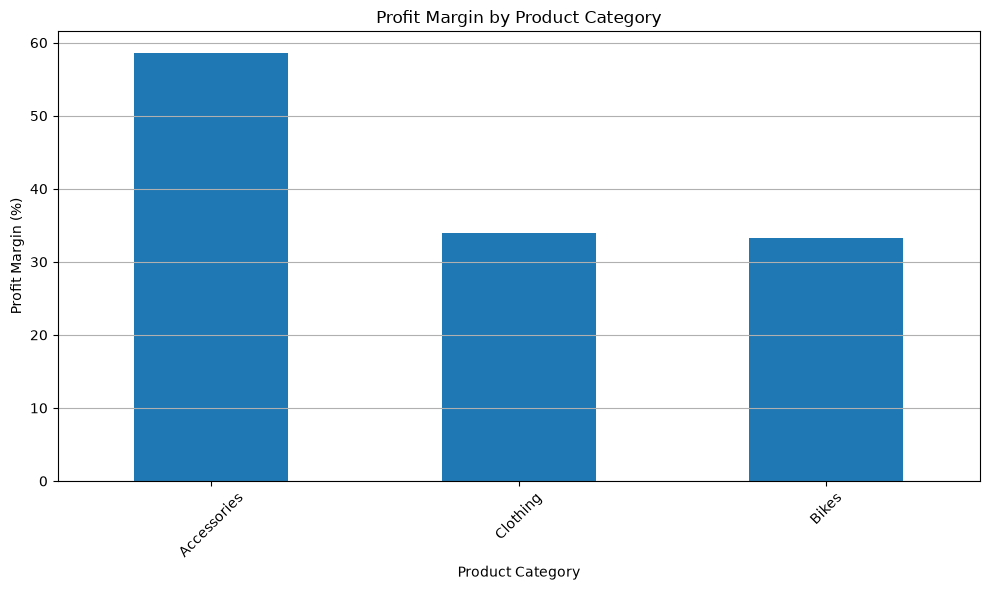

In [48]:
plt.figure(figsize=(10, 6))

category_summary['Profit_Margin_%'].plot(kind='bar')

plt.title('Profit Margin by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()

plt.show()

### Observation – Profit Margin by Product Category

The profit margin analysis reveals an important difference between revenue performance and profitability. Accessories have the highest profit margin at approximately 58.62%, despite generating less total revenue than Bikes. Clothing has a profit margin of approximately 33.92%, while Bikes have a similar margin of approximately 33.21%. This indicates that Accessories are more profitable relative to their revenue and represent an opportunity for the business to focus on high-margin products while continuing to maintain strong Bike sales.

## Business Recommendations

1. **Prioritize high-margin Accessories:** Accessories generate the highest profit margin at approximately 58.62%. The business should increase promotional campaigns, cross-selling, and product bundles for Accessories to improve overall profitability.

2. **Maintain strong Bike inventory:** Bikes are the largest revenue-generating product category. The business should maintain adequate Bike inventory and use seasonal demand patterns to plan stock levels and promotional activities.

3. **Focus on high-demand products:** Water Bottle – 30 oz. and Patch Kit/8 Patches are the top-selling products by quantity. These products should be consistently stocked and included in targeted promotional campaigns.

4. **Plan for seasonal demand:** Monthly and quarterly sales show significant fluctuations and stronger performance during later periods. Inventory, marketing campaigns, and staffing should be planned ahead of expected high-demand periods.

5. **Develop balanced customer marketing:** Adults aged 35–64 form the largest customer group, followed by Young Adults aged 25–34. Marketing campaigns should primarily address these segments while developing targeted strategies to increase engagement among Youth and Seniors.